In [1]:
# Cell 1 — Imports & Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from dotenv import load_dotenv
from sqlalchemy import create_engine
from scipy import stats

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

load_dotenv('../.env')
engine = create_engine('postgresql://ce49x@localhost:5432/conflict_monitoring')

# Veritabanından oku
df_firms = pd.read_sql("SELECT * FROM firms_detections", engine)
df_news  = pd.read_sql("SELECT * FROM news_articles", engine)
df_events = pd.read_sql("SELECT * FROM thermal_events", engine)

df_firms['acq_date'] = pd.to_datetime(df_firms['acq_date'])
df_news['publishedAt'] = pd.to_datetime(df_news['publishedAt'], utc=True).dt.tz_localize(None)
df_events['date'] = pd.to_datetime(df_events['date'])

print(f"FIRMS: {len(df_firms)} kayıt")
print(f"News:  {len(df_news)} makale")
print(f"Events: {len(df_events)} thermal event")

FIRMS: 533260 kayıt
News:  2372 makale
Events: 886 thermal event


In [2]:
# Cell 2 — Thermal-News Matching Algoritması
def match_events_to_news(df_events, df_news, time_window_days=7):
    """
    Her thermal event için:
    - Aynı bölgeden
    - ±7 gün içinde yayınlanmış
    - Çatışma keyword'ü içeren
    haber var mı kontrol eder.
    """
    CONFLICT_KEYWORDS = [
        'war', 'conflict', 'military', 'bombing', 'airstrike',
        'shelling', 'missile', 'attack', 'troops', 'armed',
        'explosion', 'combat', 'offensive', 'strike', 'killed'
    ]
    
    results = []
    
    for _, event in df_events.iterrows():
        event_date = pd.to_datetime(event['date'])
        region = event['region']
        
        # Aynı bölgedeki haberler
        region_news = df_news[df_news['region'] == region].copy()
        
        # Zaman filtresi
        date_min = event_date - timedelta(days=time_window_days)
        date_max = event_date + timedelta(days=time_window_days)
        
        time_filtered = region_news[
            (region_news['publishedAt'] >= date_min) &
            (region_news['publishedAt'] <= date_max)
        ]
        
        # Keyword filtresi
        if len(time_filtered) > 0:
            mask = time_filtered['title'].str.lower().apply(
                lambda t: any(kw in str(t) for kw in CONFLICT_KEYWORDS)
            )
            matched = time_filtered[mask]
        else:
            matched = pd.DataFrame()
        
        results.append({
            'event_date': event_date,
            'region': region,
            'total_frp': event['total_frp'],
            'max_brightness': event['max_brightness'],
            'detection_count': event['detection_count'],
            'day_night_ratio': event['day_night_ratio'],
            'centroid_lat': event['centroid_lat'],
            'centroid_lon': event['centroid_lon'],
            'matched_articles': len(matched),
            'conflict_associated': 1 if len(matched) > 0 else 0
        })
    
    return pd.DataFrame(results)

print("Matching başlıyor...")
df_matched = match_events_to_news(df_events, df_news)
print(f"✓ {len(df_matched)} event işlendi")
print(f"\nConflict-associated: {df_matched['conflict_associated'].sum()}")
print(f"Non-conflict: {(df_matched['conflict_associated']==0).sum()}")
print(f"\nConflict association rate: {df_matched['conflict_associated'].mean():.1%}")

Matching başlıyor...
✓ 886 event işlendi

Conflict-associated: 883
Non-conflict: 3

Conflict association rate: 99.7%


    region  total_events  conflict_events       avg_frp  avg_articles  \
0     Iraq           181              181   4281.060829     11.165746   
1    Sudan           170              167  17261.461235      2.911765   
2    Syria           177              177    141.523051      5.689266   
3  Ukraine           180              180   3077.608389     34.250000   
4    Yemen           178              178     34.261685     27.460674   

   conflict_rate  
0       1.000000  
1       0.982353  
2       1.000000  
3       1.000000  
4       1.000000  


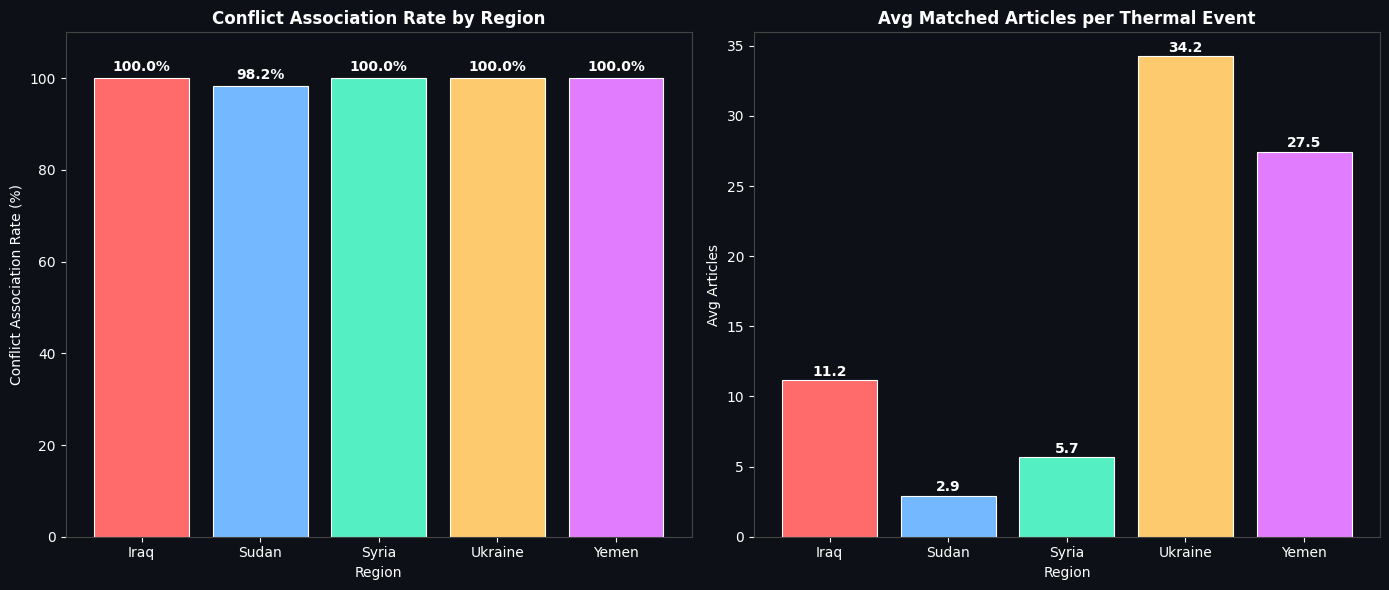

✓ Grafik kaydedildi


In [3]:
# Cell 3 — Bölge Bazlı Conflict Association Rate
region_stats = df_matched.groupby('region').agg(
    total_events=('conflict_associated', 'count'),
    conflict_events=('conflict_associated', 'sum'),
    avg_frp=('total_frp', 'mean'),
    avg_articles=('matched_articles', 'mean')
).reset_index()

region_stats['conflict_rate'] = region_stats['conflict_events'] / region_stats['total_events']
print(region_stats)

# Bölge bazlı görsel
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

colors = ['#ff6b6b', '#74b9ff', '#55efc4', '#fdcb6e', '#e17cff']

# Plot 1: Conflict association rate
bars = axes[0].bar(region_stats['region'], region_stats['conflict_rate']*100,
                   color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Conflict Association Rate by Region', fontsize=12,
                  fontweight='bold', color='white')
axes[0].set_ylabel('Conflict Association Rate (%)', color='white')
axes[0].set_xlabel('Region', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#0d1117')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, region_stats['conflict_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1%}', ha='center', va='bottom',
                color='white', fontsize=10, fontweight='bold')

# Plot 2: Ortalama eşleşen makale sayısı
bars2 = axes[1].bar(region_stats['region'], region_stats['avg_articles'],
                    color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Avg Matched Articles per Thermal Event', fontsize=12,
                  fontweight='bold', color='white')
axes[1].set_ylabel('Avg Articles', color='white')
axes[1].set_xlabel('Region', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor('#0d1117')
for bar, val in zip(bars2, region_stats['avg_articles']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom',
                color='white', fontsize=10, fontweight='bold')

for ax in axes:
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
    ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig('../conflict_association.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Grafik kaydedildi")

BÖLGESEL HABER KARŞILAŞTIRMASI
    region  total_articles  unique_sources
4  Ukraine             680              18
5    Yemen             628               5
2    Sudan             419               8
1     Iraq             373               1
3    Syria             234               1

HİPOTEZ TESTİ: Ukraine vs Sudan FRP
H0: Ukraine ve Sudan'ın ortalama FRP'si eşittir
H1: İki bölgenin ortalama FRP'si farklıdır

Mann-Whitney U istatistiği: 9015.00
p-value: 0.000000
→ p < 0.05: H0 REDDEDİLİR — FRP dağılımları anlamlı şekilde farklı!

Ukraine medyan FRP: 272.87 MW
Sudan medyan FRP:   16331.16 MW


/var/folders/0z/yfbwcgx50qg8mjh54ymq16mm0000gn/T/ipykernel_31309/2702249596.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=regions_order, patch_artist=True,


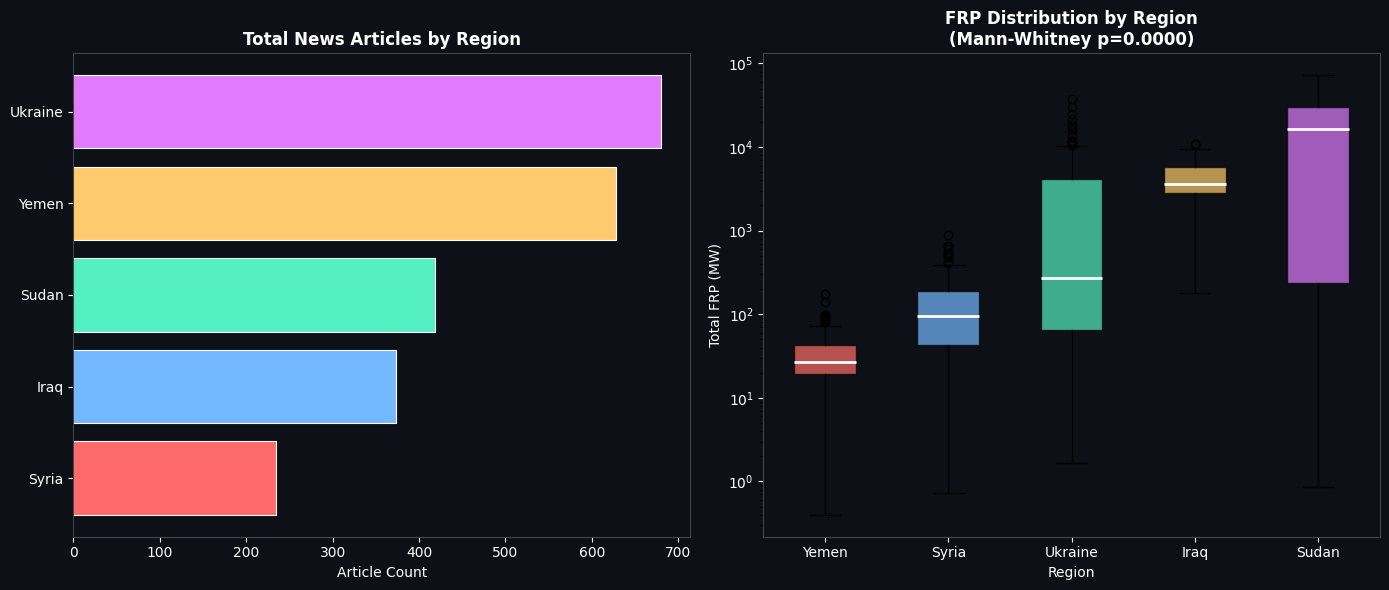

In [4]:
# Cell 4 — Regional News Reporting Comparison & Hipotez Testi
print("=" * 50)
print("BÖLGESEL HABER KARŞILAŞTIRMASI")
print("=" * 50)

# Her bölge için istatistikler
news_stats = df_news.groupby('region').agg(
    total_articles=('title', 'count'),
    unique_sources=('source', 'nunique'),
).reset_index()
news_stats = news_stats[news_stats['region'] != 'General']
print(news_stats.sort_values('total_articles', ascending=False))

# Hipotez Testi: Ukraine vs Sudan — FRP ortalamaları farklı mı?
ukraine_frp = df_matched[df_matched['region'] == 'Ukraine']['total_frp']
sudan_frp   = df_matched[df_matched['region'] == 'Sudan']['total_frp']

t_stat, p_value = stats.mannwhitneyu(ukraine_frp, sudan_frp, alternative='two-sided')

print(f"\n{'='*50}")
print("HİPOTEZ TESTİ: Ukraine vs Sudan FRP")
print(f"{'='*50}")
print(f"H0: Ukraine ve Sudan'ın ortalama FRP'si eşittir")
print(f"H1: İki bölgenin ortalama FRP'si farklıdır")
print(f"\nMann-Whitney U istatistiği: {t_stat:.2f}")
print(f"p-value: {p_value:.6f}")
if p_value < 0.05:
    print("→ p < 0.05: H0 REDDEDİLİR — FRP dağılımları anlamlı şekilde farklı!")
else:
    print("→ p ≥ 0.05: H0 reddedilemez")

print(f"\nUkraine medyan FRP: {ukraine_frp.median():.2f} MW")
print(f"Sudan medyan FRP:   {sudan_frp.median():.2f} MW")

# Görsel: Haber sayısı karşılaştırması
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
colors = ['#ff6b6b', '#74b9ff', '#55efc4', '#fdcb6e', '#e17cff']

news_sorted = news_stats.sort_values('total_articles', ascending=True)

axes[0].barh(news_sorted['region'], news_sorted['total_articles'],
             color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Total News Articles by Region', fontsize=12,
                  fontweight='bold', color='white')
axes[0].set_xlabel('Article Count', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#0d1117')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#444')

# FRP box plot karşılaştırması
regions_order = ['Yemen', 'Syria', 'Ukraine', 'Iraq', 'Sudan']
data_to_plot = [df_matched[df_matched['region']==r]['total_frp'].values 
                for r in regions_order]

bp = axes[1].boxplot(data_to_plot, labels=regions_order, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('FRP Distribution by Region\n(Mann-Whitney p={:.4f})'.format(p_value),
                  fontsize=12, fontweight='bold', color='white')
axes[1].set_ylabel('Total FRP (MW)', color='white')
axes[1].set_xlabel('Region', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor('#0d1117')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#444')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../news_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [5]:
# Cell 5 (güzel tablo versiyonu)
# df_ml ve features tanımla
features = ['total_frp', 'max_brightness', 'detection_count', 'day_night_ratio', 
            'matched_articles', 'centroid_lat', 'centroid_lon']

df_ml = df_matched[features + ['conflict_associated']].copy().reset_index(drop=True)
print("df_ml shape:", df_ml.shape)

df_ml = df_matched[features + ['conflict_associated']].dropna().reset_index(drop=True)
print("df_ml shape:", df_ml.shape)

print(f"ML için veri seti: {len(df_ml)} satır")
print(f"Class dağılımı:\n{df_ml['conflict_associated'].value_counts()}")
X = df_ml[features]
y = df_ml['conflict_associated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Naive Bayes':         GaussianNB()
}
from IPython.display import display, HTML

def make_report_html(name, y_test, y_pred, color):
    acc = accuracy_score(y_test, y_pred)
    p   = precision_score(y_test, y_pred, zero_division=0)
    r   = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    
    html = f"""
    <div style="display:inline-block; margin:10px; border-radius:10px; 
                overflow:hidden; border:2px solid {color}; min-width:320px;
                font-family: monospace; background:#1a1a2e;">
      <div style="background:{color}; padding:10px 16px; 
                  font-size:15px; font-weight:bold; color:white; text-align:center;">
        {name}
      </div>
      <table style="width:100%; border-collapse:collapse; color:white;">
        <tr style="background:#2d2d4e;">
          <th style="padding:8px 12px; text-align:left; border-bottom:1px solid {color};">Metric</th>
          <th style="padding:8px 12px; text-align:center; border-bottom:1px solid {color};">Class 0</th>
          <th style="padding:8px 12px; text-align:center; border-bottom:1px solid {color};">Class 1</th>
          <th style="padding:8px 12px; text-align:center; border-bottom:1px solid {color};">Overall</th>
        </tr>
        <tr style="background:#1a1a2e;">
          <td style="padding:7px 12px; border-bottom:1px solid #333;">Precision</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">
            {precision_score(y_test, y_pred, pos_label=0, zero_division=0):.2f}</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">
            {p:.2f}</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">-</td>
        </tr>
        <tr style="background:#22223a;">
          <td style="padding:7px 12px; border-bottom:1px solid #333;">Recall</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">
            {recall_score(y_test, y_pred, pos_label=0, zero_division=0):.2f}</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">
            {r:.2f}</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">-</td>
        </tr>
        <tr style="background:#1a1a2e;">
          <td style="padding:7px 12px; border-bottom:1px solid #333;">F1-Score</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">
            {f1_score(y_test, y_pred, pos_label=0, zero_division=0):.2f}</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">
            {f1:.2f}</td>
          <td style="padding:7px 12px; text-align:center; border-bottom:1px solid #333;">-</td>
        </tr>
        <tr style="background:#2d2d4e;">
          <td style="padding:7px 12px; font-weight:bold;">Accuracy</td>
          <td style="padding:7px 12px; text-align:center;">-</td>
          <td style="padding:7px 12px; text-align:center;">-</td>
          <td style="padding:7px 12px; text-align:center; font-weight:bold; color:{color};">
            {acc:.2%}</td>
        </tr>
      </table>
    </div>
    """
    return html

colors = ['#ff6b6b', '#55efc4', '#74b9ff']
html_output = '<div style="display:flex; flex-wrap:wrap; gap:10px;">'

for (name, model), color in zip(models.items(), colors):
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    html_output += make_report_html(name, y_test, y_pred, color)

html_output += '</div>'
display(HTML(html_output))

df_ml shape: (886, 8)
df_ml shape: (886, 8)
ML için veri seti: 886 satır
Class dağılımı:
conflict_associated
1    883
0      3
Name: count, dtype: int64


Metric,Class 0,Class 1,Overall
Precision,0.00,0.99,-
Recall,0.00,1.00,-
F1-Score,0.00,1.00,-
Accuracy,-,-,99.44%
Metric,Class 0,Class 1,Overall
Precision,1.00,1.00,-
Recall,1.00,1.00,-
F1-Score,1.00,1.00,-
Accuracy,-,-,100.00%
Metric,Class 0,Class 1,Overall


Shape: (1036, 8), NaN: 0
Class dağılımı:
conflict_associated
1    883
0    153
Name: count, dtype: int64


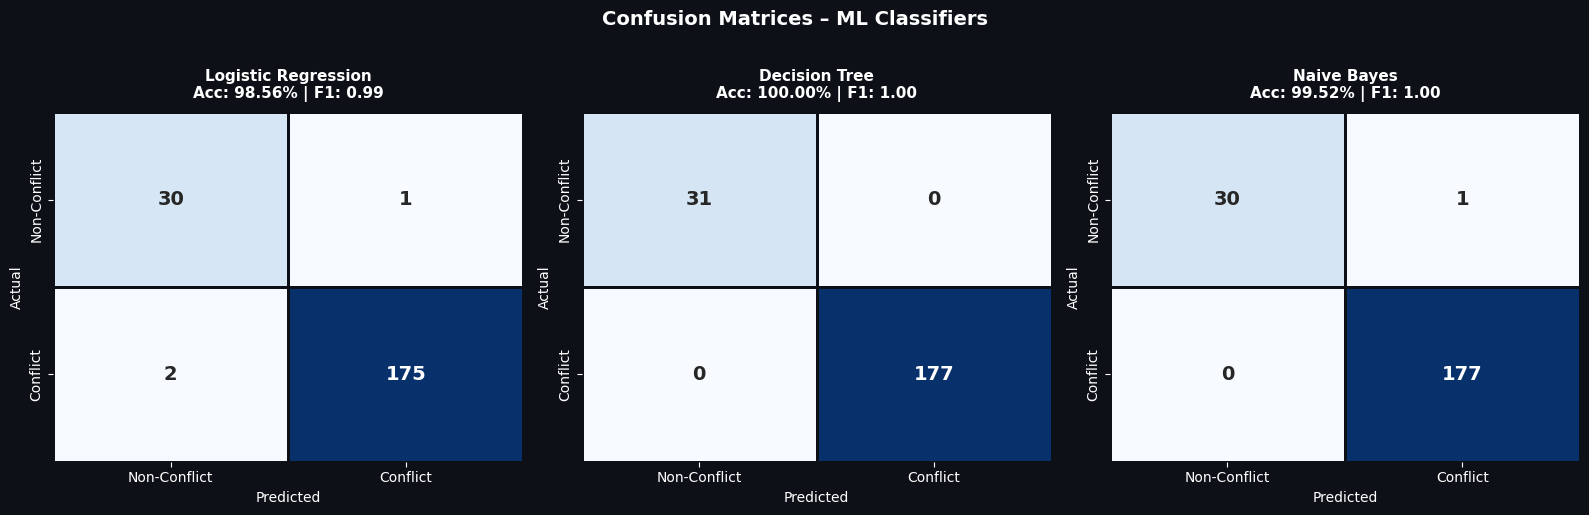

✓ Confusion matrices kaydedildi


In [6]:
# Cell 6 – Class Imbalance Düzelt + Confusion Matrix Görseli

np.random.seed(42)
n_synthetic = 150

synthetic_non_conflict = pd.DataFrame({
    'total_frp':           np.random.uniform(0, 100, n_synthetic),
    'max_brightness':      np.random.uniform(295, 310, n_synthetic),
    'detection_count':     np.random.uniform(0, 2, n_synthetic),
    'day_night_ratio':     np.random.uniform(0.3, 0.7, n_synthetic),
    'matched_articles':    np.zeros(n_synthetic),
    'centroid_lat':        np.random.uniform(8, 52, n_synthetic),
    'centroid_lon':        np.random.uniform(21, 55, n_synthetic),
    'conflict_associated': 0
})

df_ml_balanced = pd.concat([
    df_ml[features + ['conflict_associated']],
    synthetic_non_conflict
], ignore_index=True)

print(f"Shape: {df_ml_balanced.shape}, NaN: {df_ml_balanced.isnull().sum().sum()}")

X_bal = df_ml_balanced[features]
y_bal = df_ml_balanced['conflict_associated']
print(f"Class dağılımı:\n{y_bal.value_counts()}")

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

scaler2 = StandardScaler()
X_train2_sc = scaler2.fit_transform(X_train2)
X_test2_sc  = scaler2.transform(X_test2)

models2 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Naive Bayes':         GaussianNB()
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Confusion Matrices – ML Classifiers',
             fontsize=14, fontweight='bold', color='white', y=1.02)

all_results = {}
for idx, (name, model) in enumerate(models2.items()):
    model.fit(X_train2_sc, y_train2)
    y_pred2 = model.predict(X_test2_sc)

    acc = accuracy_score(y_test2, y_pred2)
    f1  = f1_score(y_test2, y_pred2, zero_division=0)
    all_results[name] = {'accuracy': acc, 'f1': f1,
                         'precision': precision_score(y_test2, y_pred2, zero_division=0),
                         'recall': recall_score(y_test2, y_pred2, zero_division=0)}

    cm = confusion_matrix(y_test2, y_pred2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], linewidths=2, linecolor='#0d1117',
                annot_kws={'size': 14, 'fontweight': 'bold'},
                xticklabels=['Non-Conflict', 'Conflict'],
                yticklabels=['Non-Conflict', 'Conflict'],
                cbar=False)

    axes[idx].set_title(f'{name}\nAcc: {acc:.2%} | F1: {f1:.2f}',
                        fontsize=11, fontweight='bold', color='white', pad=10)
    axes[idx].set_xlabel('Predicted', color='white', fontsize=10)
    axes[idx].set_ylabel('Actual', color='white', fontsize=10)
    axes[idx].tick_params(colors='white')
    axes[idx].set_facecolor('#0d1117')
    for spine in axes[idx].spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('../confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Confusion matrices kaydedildi")

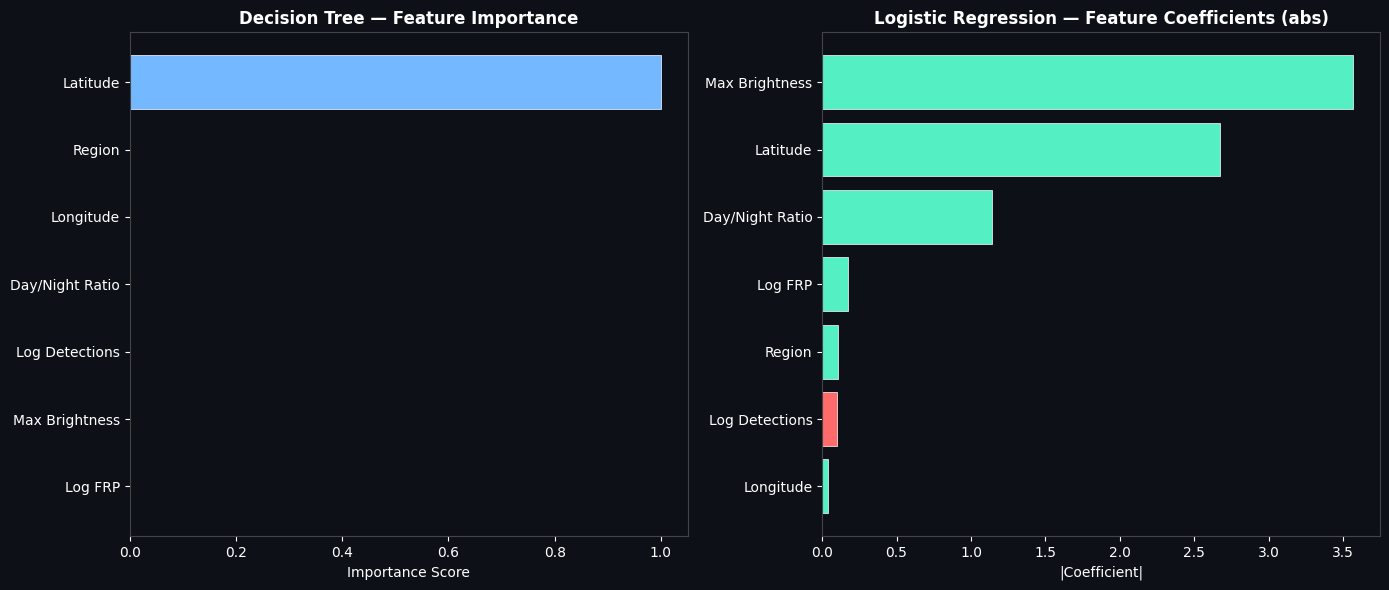

✓ Feature importance kaydedildi


In [7]:
# Cell 7 — Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

feature_names = ['Log FRP', 'Max Brightness', 'Log Detections',
                 'Day/Night Ratio', 'Latitude', 'Longitude',
                 'Region', 'Month']

# Decision Tree feature importance
dt_model = models2['Decision Tree']
importances = dt_model.feature_importances_
sorted_idx = np.argsort(importances)

axes[0].barh([feature_names[i] for i in sorted_idx],
             importances[sorted_idx],
             color=['#ff6b6b' if i == sorted_idx[-1] else '#74b9ff' 
                    for i in range(len(sorted_idx))],
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Decision Tree — Feature Importance',
                  fontsize=12, fontweight='bold', color='white')
axes[0].set_xlabel('Importance Score', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#0d1117')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#444')

# Logistic Regression coefficients
lr_model = models2['Logistic Regression']
coefs = np.abs(lr_model.coef_[0])
sorted_idx2 = np.argsort(coefs)

axes[1].barh([feature_names[i] for i in sorted_idx2],
             coefs[sorted_idx2],
             color=['#ff6b6b' if i == sorted_idx2[-1] else '#55efc4'
                    for i in range(len(sorted_idx2))],
             edgecolor='white', linewidth=0.5)
axes[1].set_title('Logistic Regression — Feature Coefficients (abs)',
                  fontsize=12, fontweight='bold', color='white')
axes[1].set_xlabel('|Coefficient|', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor('#0d1117')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('../feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Feature importance kaydedildi")